In [1]:
import numpy as np
w = h = 8
map = (np.random.rand(h, w) > 0.75).astype(np.float32)


In [1]:
import numpy as np
from pathlib import Path

DOMAIN = 'game'
MAP = 'brc202d.map'
WALLS = ['T', '@']
maps_path = Path(f'../example_problems/{DOMAIN}.domain/maps/')
map_path = maps_path / MAP

In [3]:
with map_path.open() as f:
    lines = f.readlines()
lines = [line.strip() for line in lines if line.strip()]
lines = lines[4:] # ignore headers

map = np.array([list(line) for line in lines])
map = np.where(np.isin(map, WALLS), 1, 0).astype(np.bool)
h, w = map.shape

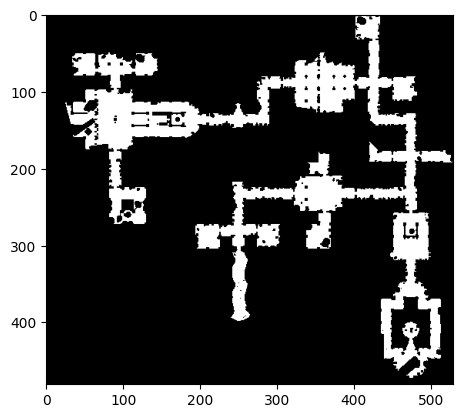

In [4]:
import matplotlib.pyplot as plt

plt.imshow(1 - map, cmap='gray')

In [5]:
valid_locs = np.vstack(np.where(map == 0)).T
len(valid_locs)

43151

In [11]:
num_agents = 500
agents_idxs = np.random.choice(len(valid_locs), num_agents, replace=False)
agents_idxs = valid_locs[agents_idxs]
orientations = np.random.randint(4, size=num_agents)
agents_idxs = np.hstack([agents_idxs, orientations[:, None]])
agents_locs = np.zeros((h, w, 4))
agents_locs[agents_idxs[:, 0], agents_idxs[:, 1], agents_idxs[:, 2]] = 1

agents_locs = agents_locs.transpose(2, 0, 1)

In [12]:
agents_locs

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [13]:
agents_locs.sum()

np.float64(500.0)

In [14]:
def visualize_map_probs(map, agents_probs):
    map_viz = np.tile(1 - map[np.newaxis, :, :], (3, 1, 1)).astype(np.float32)
    map_viz[1,:,:] -= agents_probs.sum(axis=0)
    plt.imshow(map_viz.transpose(1, 2, 0))

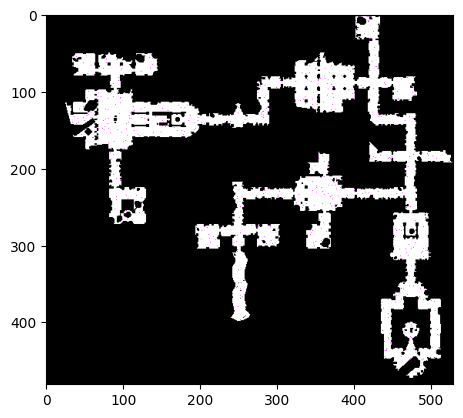

In [15]:
visualize_map_probs(map, agents_locs)

In [16]:
kernels = np.array([
    [
        [
            [0, 0, 0],
            [1, 1, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 1, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 1, 0],
            [0, 0, 0],
        ],
    ],
    [
        [
            [0, 0, 0],
            [0, 1, 0],
            [0, 0, 0],
        ],
        [
            [0, 1, 0],
            [0, 1, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 1, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
    ],
    [
        [
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 1, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 1, 1],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 1, 0],
            [0, 0, 0],
        ],
    ],
    [
        [
            [0, 0, 0],
            [0, 1, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 1, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 1, 0],
            [0, 1, 0],
        ],
    ],
], dtype=np.float32)

kernels /= 4

In [17]:
wall_reflection_kernel = np.array([
    [
        [0, 0, 0],
        [0, 0, 1],
        [0, 0, 0],
    ],
    [
        [0, 0, 0],
        [0, 0, 0],
        [0, 1, 0],
    ],
    [
        [0, 0, 0],
        [1, 0, 0],
        [0, 0, 0],
    ],
    [
        [0, 1, 0],
        [0, 0, 0],
        [0, 0, 0],
    ],
], dtype=np.float32)
wall_reflection_kernel /= 4

In [18]:
from scipy import signal

reflection_prob_map = np.zeros((4, h, w))
map_dir = np.tile(map[np.newaxis, :, :], (4, 1, 1))
for curr_d in range(4):
    reflection_prob_map[curr_d] += signal.convolve2d(
        map_dir[curr_d],
        wall_reflection_kernel[curr_d],
        mode='same',
        fillvalue=1,
    )

reflection_prob_map *= (1 - map_dir)

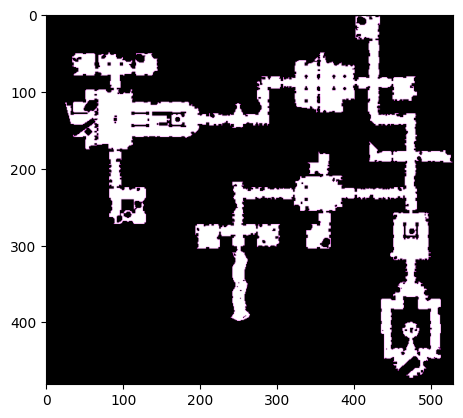

In [19]:
visualize_map_probs(map, (reflection_prob_map * (1 - map_dir)))

In [20]:
import numpy as np
from numba import njit
from numba.typed import List

@njit
def get_active_cells(state, pad=1):
    """Find cells that need convolution (agents and adjacent cells)"""
    h, w = state.shape
    active = set()
    
    # Find cells with agents and their neighbors
    for i in range(h):
        for j in range(w):
            if state[i, j] > 0:
                # Add cell and all adjacent cells
                for di in [-1, 0, 1]:
                    for dj in [-1, 0, 1]:
                        ni, nj = i + di, j + dj
                        # Handle padding - we keep these coordinates even if out of bounds
                        active.add((ni, nj))
    
    return List(active)

@njit
def sparse_conv2d_padded(state, kernel, walls):
    """
    Custom convolution only on active cells with proper padding
    
    Args:
        state: 2D array (h x w) with agent probabilities
        kernel: 2D array (3 x 3) with transition probabilities
        walls: 2D boolean array (h x w) where True indicates walls
    """
    h, w = state.shape
    result = np.zeros_like(state)
    
    # Get cells that need processing
    active_cells = get_active_cells(state)
    
    # Only process active cells that aren't walls and are within bounds
    for (i, j) in active_cells:
        # Skip if target cell is out of bounds or is a wall
        if i < 0 or i >= h or j < 0 or j >= w or walls[i, j]:
            continue
            
        # Apply kernel
        value = 0.0
        for ki in range(3):
            for kj in range(3):
                # Get source cell indices (kernel is centered on i,j)
                si = i + (ki - 1)
                sj = j + (kj - 1)
                
                # Handle padding - treat out of bounds as zero
                if 0 <= si < h and 0 <= sj < w:
                    if not walls[si, sj]:
                        value += state[si, sj] * kernel[ki, kj]
                
        result[i, j] = value
    
    return result

@njit
def apply_transition_sparse(state, kernels, walls):
    """
    Apply transition using sparse convolution
    
    Args:
        state: 4xhxw array with agent probabilities
        kernels: 4x4x3x3 array with transition kernels
        walls: hxw boolean array where True indicates walls
    """
    result = np.zeros_like(state)
    
    for curr_d in range(4):
        if not np.any(state[curr_d]):
            continue
            
        for target_d in range(4):
            result[target_d] += sparse_conv2d_padded(
                state[curr_d],
                kernels[curr_d, target_d],
                walls
            )
    
    return result

In [21]:
import numpy as np
from scipy.signal import fftconvolve

def apply_transition_fast(state, map, kernels):
    """
    Apply transition kernels to a state matrix using vectorized operations.
    
    Args:
        state: 4x3x3 numpy array representing current state probabilities
              (4 directions x 3x3 grid)
        kernels: 4x4x3x3 numpy array representing transition probabilities
                First dim: current direction
                Second dim: target direction
                Last two dims: spatial transition probabilities
    
    Returns:
        4x3x3 numpy array with next state probabilities
    """
    result = np.zeros_like(state)

    # For each current direction
    for curr_d in range(4):
        for target_d in range(4):
            result[target_d] += fftconvolve(
                state[curr_d],
                kernels[curr_d, target_d],
                mode='same'
            )
    result = result * (1 - map_dir) # Apply map mask
    result += state * reflection_prob_map # Apply reflection probabilities
    
    return result

def iterate_transitions_fast(initial_state, map, kernels, steps):
    """
    Compute probability distribution after multiple steps.
    
    Args:
        initial_state: 4x3x3 numpy array representing initial state
        kernels: 4x4x3x3 numpy array of pre-computed transition kernels
        steps: number of time steps to simulate
    
    Returns:
        List of 4x3x3 numpy arrays representing state at each time step
    """
    states = [initial_state]
    current_state = initial_state
    
    for _ in range(steps):
        current_state = apply_transition_fast(current_state, map, kernels)
        states.append(current_state)
    
    return states


In [22]:
import numpy as np
from numba import njit, prange

@njit(parallel=True)
def apply_sparse_convolution(state, map_dir, reflection_prob_map, kernels):
    """
    Optimized sparse convolution with Numba using pre-allocated arrays and parallelism.
    """
    H, W = state.shape[1], state.shape[2]
    result = np.zeros_like(state)
    kernel_size = 1

    # Iterate through all cells in parallel
    for i in prange(H):
        for j in prange(W):
            if map_dir[i, j] == 1:
                continue  # Skip walls

            for curr_d in range(4):
                if state[curr_d, i, j] == 0:
                    continue  # Skip zero-probability cells

                for target_d in range(4):
                    kernel = kernels[curr_d, target_d]

                    # Apply kernel to the neighborhood
                    for di in range(-kernel_size, kernel_size + 1):
                        for dj in range(-kernel_size, kernel_size + 1):
                            ni, nj = i + di, j + dj
                            if 0 <= ni < H and 0 <= nj < W and map_dir[ni, nj] == 0:
                                result[target_d, ni, nj] += state[curr_d, i, j] * kernel[di + kernel_size, dj + kernel_size]

                result[curr_d, i, j] += state[curr_d, i, j] * reflection_prob_map[curr_d, i, j]
    return result

def iterate_transitions_sparse(initial_state, map_dir, reflection_prob_map, kernels, steps):
    """
    Compute probability distribution after multiple steps using optimized sparse convolution.
    """

    states = [initial_state]
    current_state = initial_state

    for _ in range(steps):
        current_state = apply_sparse_convolution(current_state, map_dir, reflection_prob_map, kernels)
        states.append(current_state)

    return states

In [23]:
%%timeit 
t1 = apply_transition_fast(agents_locs, map, kernels)

91.2 ms ± 7.92 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [24]:
%%timeit
t1 = apply_sparse_convolution(agents_locs, map, reflection_prob_map, kernels)

853 μs ± 46.6 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [25]:
t1 = apply_sparse_convolution(agents_locs, map, reflection_prob_map, kernels)

In [26]:
t1.sum()

np.float64(500.0)

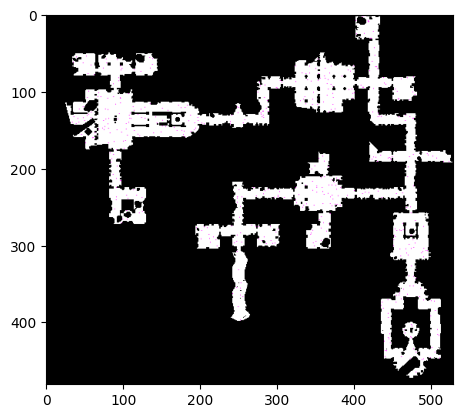

In [27]:
visualize_map_probs(map, t1)

In [28]:
%%timeit
t50 = iterate_transitions_fast(agents_locs, map, kernels, 50)

3.05 s ± 157 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [29]:
%%timeit
t50 = iterate_transitions_sparse(agents_locs.copy(), map, reflection_prob_map, kernels, 50)

85.8 ms ± 2.67 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [30]:
t50 = iterate_transitions_sparse(agents_locs.copy(), map, reflection_prob_map, kernels, 100)

In [31]:
t50[99].sum()

np.float64(499.99999999999983)

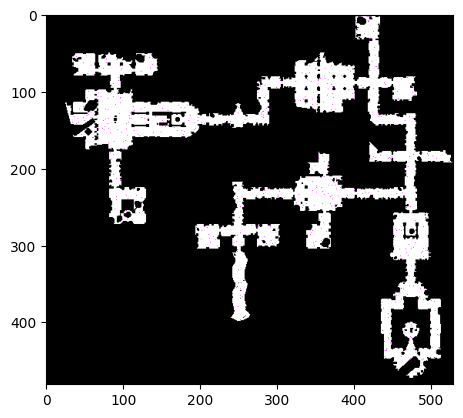

In [32]:
visualize_map_probs(map, t50[0])

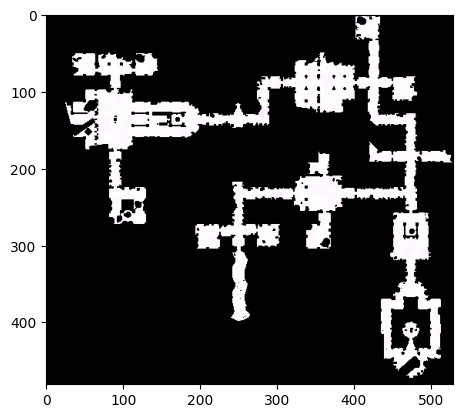

In [34]:
visualize_map_probs(map, t50[40])

In [230]:
t50[0].max()

np.float64(1.0)